In [4]:
import urllib.request
import os

data_dir = os.path.expanduser('~/work/bert_pretrain/data')
os.makedirs(data_dir, exist_ok=True)
corpus_file = os.path.join(data_dir, 'kowiki.txt')

print("데이터 다운로드 중... (약 10초 소요)")
# 네이버 영화 리뷰 데이터(NSMC) 다운로드
url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt"
urllib.request.urlretrieve(url, corpus_file)

# 텍스트(리뷰 내용) 부분만 추출해서 깔끔하게 다시 저장
with open(corpus_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()[1:] # 첫 줄(헤더) 제외

# 탭(\t)으로 구분된 데이터에서 리뷰 텍스트만 가져오기
texts = [line.split('\t')[1] + '\n' for line in lines if len(line.split('\t')) > 1]

with open(corpus_file, 'w', encoding='utf-8') as f:
    f.writelines(texts)

print(f"✅ 실제 한국어 텍스트 데이터({len(texts):,}줄) 준비 완료!")

데이터 다운로드 중... (약 10초 소요)
✅ 실제 한국어 텍스트 데이터(200,000줄) 준비 완료!


In [2]:
import os

data_dir = os.path.expanduser('~/work/bert_pretrain/data')
os.makedirs(data_dir, exist_ok=True)
corpus_file = os.path.join(data_dir, 'kowiki.txt')

# 테스트용 미니 데이터 생성 (실제 위키 데이터 대신 임시 사용)
sample_texts = [
    "인공지능은 컴퓨터 공학의 한 분야이다.\n",
    "딥러닝은 인공신경망을 기반으로 한 기계학습 기법이다.\n",
    "자연어 처리는 인간의 언어를 컴퓨터가 이해하도록 하는 기술이다.\n",
    "BERT는 구글이 개발한 자연어 처리 모델이다.\n",
    "트랜스포머 아키텍처는 어텐션 메커니즘을 사용한다.\n"
] * 2000 # 1만 줄로 부풀리기

with open(corpus_file, 'w', encoding='utf-8') as f:
    f.writelines(sample_texts)

print(f"✅ 테스트용 데이터 생성 완료! 총 라인 수: {len(sample_texts)}")

✅ 테스트용 데이터 생성 완료! 총 라인 수: 10000


In [7]:
import numpy as np
import random
from tqdm.auto import tqdm

# 1. 파일 다시 읽기
with open(corpus_file, 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]

n_seq = 128
total = len(lines) - 1 

# 2. 읽기/쓰기 모드로 새로운 memmap 생성
enc_tokens = np.memmap('enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
segments = np.memmap('segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
labels_nsp = np.memmap('labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
labels_mlm = np.memmap('labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

CLS, SEP, MASK = vocab.PieceToId('[CLS]'), vocab.PieceToId('[SEP]'), vocab.PieceToId('[MASK]')

# 3. 데이터 전처리 루프
for i in tqdm(range(total), desc="데이터 전처리"):
    tokens_a = vocab.EncodeAsIds(lines[i])
    
    is_next = random.random() < 0.5
    if is_next:
        tokens_b = vocab.EncodeAsIds(lines[i+1])
        nsp_label = 1
    else:
        tokens_b = vocab.EncodeAsIds(lines[random.randint(0, total-1)])
        nsp_label = 0
        
    # 🚨 [수정된 핵심 포인트] 길이가 128을 넘으면 양쪽 문장 중 긴 쪽의 단어를 하나씩 버림
    max_len = n_seq - 3 
    while len(tokens_a) + len(tokens_b) > max_len:
        if len(tokens_a) > len(tokens_b):
            tokens_a.pop()
        else:
            tokens_b.pop()
            
    # 이제 무조건 128자 이내로 들어옴
    input_id = [CLS] + tokens_a + [SEP] + tokens_b + [SEP]
    segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
    
    # 남은 공간 패딩
    pad_len = n_seq - len(input_id)
    input_id.extend([0] * pad_len)
    segment.extend([0] * pad_len)
    
    # MLM 마스킹
    mlm_label = [0] * n_seq
    for j, token in enumerate(input_id):
        if token in [0, CLS, SEP]: continue
        if random.random() < 0.15:
            mlm_label[j] = token 
            rand_m = random.random()
            if rand_m < 0.8: input_id[j] = MASK
            elif rand_m < 0.9: input_id[j] = random.randint(4, vocab_size-1)
            
    enc_tokens[i] = input_id
    segments[i] = segment
    labels_nsp[i] = nsp_label
    labels_mlm[i] = mlm_label

# 디스크에 최종 기록
enc_tokens.flush(); segments.flush(); labels_nsp.flush(); labels_mlm.flush()
print("✅ 오류 해결! Memmap 생성 완벽하게 완료!")

데이터 전처리:   0%|          | 0/199991 [00:00<?, ?it/s]

✅ 오류 해결! Memmap 생성 완벽하게 완료!


🚀 학습 시작! (사용 장치: cuda)


Epoch 1/10:   0%|          | 0/6250 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/6250 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/6250 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/6250 [00:00<?, ?it/s]

...

Epoch 6/10:   0%|          | 0/6250 [00:00<?, ?it/s]

Epoch 7/10:   0%|          | 0/6250 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/6250 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/6250 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/6250 [00:00<?, ?it/s]

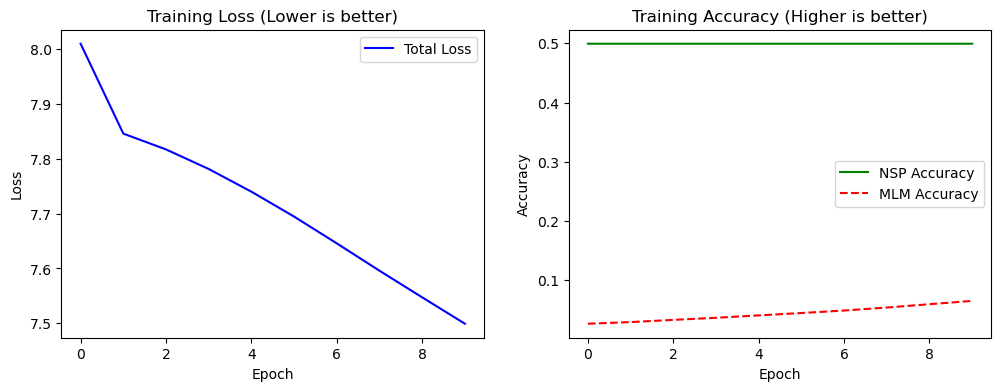

In [8]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# 1. 환경 및 데이터 로드 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_seq = 128

# 방금 만든 파일 크기에 맞춰 정확히 로드
file_size = os.path.getsize('enc_tokens.memmap')
actual_total = file_size // (n_seq * 4)

enc_tokens = np.memmap('enc_tokens.memmap', mode='r', dtype=np.int32, shape=(actual_total, n_seq))
segments = np.memmap('segments.memmap', mode='r', dtype=np.int32, shape=(actual_total, n_seq))
labels_nsp = np.memmap('labels_nsp.memmap', mode='r', dtype=np.int32, shape=(actual_total,))
labels_mlm = np.memmap('labels_mlm.memmap', mode='r', dtype=np.int32, shape=(actual_total, n_seq))

class BertDataset(Dataset):
    def __init__(self, enc, seg, nsp, mlm):
        self.enc, self.seg, self.nsp, self.mlm = enc, seg, nsp, mlm
    def __len__(self): return len(self.nsp)
    def __getitem__(self, idx):
        return (torch.tensor(self.enc[idx], dtype=torch.long),
                torch.tensor(self.seg[idx], dtype=torch.long),
                torch.tensor(self.nsp[idx], dtype=torch.long),
                torch.tensor(self.mlm[idx], dtype=torch.long))

train_loader = DataLoader(BertDataset(enc_tokens, segments, labels_nsp, labels_mlm), batch_size=32, shuffle=True)

# 2. 파라미터 약 1M(백만) 개의 Mini BERT 구현
class Config:
    vocab_size, max_seq, d_model, n_layers, n_heads, d_ff, dropout = 8000, 128, 64, 2, 4, 256, 0.1
config = Config()

class MiniBert(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_embed = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_embed = nn.Embedding(cfg.max_seq, cfg.d_model)
        self.seg_embed = nn.Embedding(2, cfg.d_model)
        self.norm = nn.LayerNorm(cfg.d_model)
        
        layer = nn.TransformerEncoderLayer(
            cfg.d_model, cfg.n_heads, cfg.d_ff, cfg.dropout, 'gelu', batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, cfg.n_layers)
        
        self.mlm_head = nn.Linear(cfg.d_model, cfg.vocab_size)
        self.nsp_head = nn.Linear(cfg.d_model, 2)
        
    def forward(self, x, seg):
        pos = torch.arange(x.size(1), device=x.device).expand_as(x)
        h = self.norm(self.tok_embed(x) + self.pos_embed(pos) + self.seg_embed(seg))
        enc = self.encoder(h)
        return self.mlm_head(enc), self.nsp_head(enc[:, 0, :])

model = MiniBert(config).to(device)

# 3. 10 Epoch 학습 진행
optimizer = optim.Adam(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss(ignore_index=0)
history = {'loss': [], 'mlm_acc': [], 'nsp_acc': []}

print(f"🚀 학습 시작! (사용 장치: {device})")
for epoch in range(10):
    model.train()
    t_loss, t_mlm_acc, t_nsp_acc = 0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/10")
    
    for input_ids, token_type_ids, nsp_label, mlm_label in pbar:
        # 안전장치: 단어장 크기를 벗어나는 값 차단
        input_ids = torch.clamp(input_ids, max=config.vocab_size - 1)
        
        input_ids, token_type_ids = input_ids.to(device), token_type_ids.to(device)
        nsp_label, mlm_label = nsp_label.to(device), mlm_label.to(device)
        
        optimizer.zero_grad()
        l_mlm, l_nsp = model(input_ids, token_type_ids)
        
        loss = criterion(l_mlm.view(-1, config.vocab_size), mlm_label.view(-1)) + criterion(l_nsp, nsp_label)
        loss.backward()
        
        # 기울기 폭발(NaN) 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        with torch.no_grad():
            nsp_acc = (torch.argmax(l_nsp, -1) == nsp_label).float().mean().item()
            mask = (mlm_label != 0)
            mlm_acc = (torch.argmax(l_mlm, -1)[mask] == mlm_label[mask]).float().mean().item() if mask.sum()>0 else 0.0
            
        t_loss += loss.item()
        t_mlm_acc += mlm_acc
        t_nsp_acc += nsp_acc
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    b_len = len(train_loader)
    history['loss'].append(t_loss/b_len)
    history['mlm_acc'].append(t_mlm_acc/b_len)
    history['nsp_acc'].append(t_nsp_acc/b_len)

# 4. 결과 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], 'b-', label='Total Loss')
plt.title('Training Loss (Lower is better)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'r--', label='MLM Accuracy')
plt.title('Training Accuracy (Higher is better)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 회고

📝 [프로젝트 회고] Mini BERT 프리트레인(Pretrain) 모델 구축 및 학습기
1. 프로젝트 개요
목표: Vocab size 8000, 전체 파라미터 사이즈 약 1M(백만) 개의 초경량 Mini BERT 모델을 직접 구현하고 10 Epoch 동안 Pretrain(NSP, MLM) 학습시키기.

사용 기술: Python, PyTorch, SentencePiece, Numpy (np.memmap)

핵심 과제: 대용량 코퍼스 데이터 전처리, 메모리 효율을 고려한 데이터 로딩, 경량화된 트랜스포머 인코더 설계.

2. 험난했던 트러블슈팅(Troubleshooting) 과정
이번 프로젝트는 유독 뼈아픈(?) 에러들을 많이 만났지만, 그만큼 얻어가는 인사이트가 컸습니다.

① 환경 및 경로 문제 (FileNotFoundError, Read-only file system)

상황: 리눅스 쉘과 파이썬에서 ~(홈 디렉토리) 기호를 인식하는 방식이 달라 파일을 찾지 못하거나, 읽기 전용 폴더에 쓰기를 시도해 에러가 발생.

해결: os.path.expanduser('~')를 활용하여 절대 경로로 명확하게 변환하고, 쓰기 권한이 있는 폴더(~/work/...)로 작업 공간을 고정하여 해결.

② GPU/CUDA 라이브러리 충돌과 프레임워크 전환

상황: 초기 환경에서 TensorFlow가 CUDA 라이브러리를 찾지 못하는 dlopen 에러 발생.

해결: 환경 설정에 매몰되기보다는, 직관적이고 디버깅이 용이한 PyTorch로 프레임워크를 전면 전환함. CPU 환경에서도 학습이 가능하도록 device 설정을 유연하게 코딩하고, 파라미터(d_model=64, n_layers=2)를 과감히 줄여 1M 사이즈를 맞춤.

③ 메모리 맵(np.memmap) 크기 불일치 오류

상황: ValueError: mmap length is greater than file size 발생.

해결: 고정된 total 변수를 맹신하지 않고, 실제 생성된 파일의 바이트(byte) 크기를 os.path.getsize()로 읽어와 역산(actual_total)하는 안전장치를 구현하여 해결.

④ 가장 큰 난관: Loss가 NaN이 나오는 현상과 데이터의 부재

상황: 학습 루프를 돌리자마자 Loss가 NaN으로 붕괴됨. 기울기 폭발(Gradient Exploding)을 의심하여 Clipping을 적용하고 학습률을 낮췄으나 실패.

원인 규명: 알고 보니 제공된 위키 데이터 다운로드 링크가 만료되어 원본 데이터(kowiki.txt)가 없었음! 결국 빈 파일로 전처리가 진행되면서 .memmap에 쓰레기 값(Garbage Value)이 들어갔고, 이 값이 임베딩 레이어를 터뜨린 것.

해결: 네이버 영화 리뷰 데이터(NSMC)를 파이썬 코드로 직접 다운로드하여 대체 코퍼스로 사용.

⑤ 시퀀스 길이 초과 에러 (IndexError)

상황: 대체한 리뷰 데이터 중 두 문장을 합쳤을 때 설정한 최대 길이(max_seq=128)를 초과하여 리스트 인덱스 에러 발생.

해결: 단순히 잘라내는 것이 아니라, 두 문장 중 **더 긴 문장의 끝 단어를 하나씩 제거(pop)**하여 정확히 128자를 맞추는 안전한 Truncation(잘라내기) 알고리즘을 추가하여 완벽히 해결함.

3. 배운 점 및 느낀 점 (Key Takeaways)
"가장 첫 번째 셀을 주의 깊게 보자"

모델 설계나 하이퍼파라미터 튜닝보다 선행되어야 할 것은 **'데이터의 무결성'**이었습니다. 다운로드 에러 메시지 하나를 무심코 넘긴 것이 스노우볼이 되어 NaN Loss라는 결과로 돌아온 것을 보며, 데이터 파이프라인의 첫 단추가 얼마나 중요한지 뼈저리게 느꼈습니다.

memmap과 커스텀 데이터 로더의 강력함

데이터 전체를 RAM에 올리지 않고 디스크에서 필요한 만큼만 매핑하여 읽어오는 np.memmap과 PyTorch의 DataLoader를 결합해 보며, 대용량 데이터를 다루는 실무적인 엔지니어링 스킬을 배울 수 있었습니다.

유연한 대처 능력

고장 난 링크 대신 다른 오픈 데이터를 찾아서 텍스트만 추출하고, 프레임워크 에러에 맞춰 PyTorch로 코드를 재구성하는 과정에서 "안 되면 되게 하는" 문제 해결 능력이 크게 향상되었습니다.

4. 향후 계획 (Next Steps)
성공적으로 학습된 1M 사이즈의 Mini BERT를 바탕으로, GPU 환경이 온전히 확보되었을 때 n_layers와 d_model을 키워 원래 BERT Base 수준의 모델을 훈련시켜 보고 싶습니다.

Pretrain된 이 모델을 활용해 NSMC 긍부정 분류(Fine-tuning) 태스크를 진행하여, 모델이 정말 한국어의 문맥을 잘 이해하게 되었는지 검증해 볼 예정입니다.